In [20]:
import os
import math
import random
import sys
import json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoConfig

# Reproducibility
np.random.seed(0)
torch.manual_seed(0)

torch.set_float32_matmul_precision("high")

# paths (aligned with 01-2.motivation_toy.ipynb)
os.chdir('/home/seunghan.lee/workspace/cross-rag/motivation/')
ROOT = Path('cross-rag/').resolve().parent.parent  # /home/.../workspace/cross-rag
sys.path.append(str(ROOT / "cross-rag"))
BASE_CONFIG_DIR = ROOT / "checkpoints" / "base"
DUALHEAD_CKPT_DIR = ROOT / "checkpoints" / "pretrain_Chronos_lb512_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7"
DUALHEAD_CKPT = DUALHEAD_CKPT_DIR / "best.pth"

import sys
sys.path.append(str(ROOT))

from models.ChronosBolt import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_base
from models.ChronosBolt_TabPFN_dualhead_R_as_key import ChronosBoltModelForForecastingWithRetrieval as ChronosBoltModelForForecastingWithRetrieval_ours

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


print("ROOT:", ROOT)
print("DUALHEAD_CKPT:", DUALHEAD_CKPT)
print("device:", device)
assert DUALHEAD_CKPT.exists(), "checkpoint not found; update path if needed"
assert BASE_CONFIG_DIR.exists(), "base config dir not found"

# helper to load model (mirrors 01-2.motivation_toy)
def load_model(ckpt_file: Path, cls, augment: str | None = None):
    cfg = AutoConfig.from_pretrained(BASE_CONFIG_DIR, trust_remote_code=True)
    state = torch.load(ckpt_file, map_location=device)
    extra = {"augment": augment} if augment is not None else {}
    model = cls.from_pretrained(BASE_CONFIG_DIR, config=cfg, state_dict=state, **extra)
    return model.to(device).eval()

model = load_model(DUALHEAD_CKPT, ChronosBoltModelForForecastingWithRetrieval_ours, augment="moe")

# configs
context_len = 512
pred_len = 64
N = 100          # knowledge base size
k_top = 5        # top-k to retrieve

sns.set_style("whitegrid")



ROOT: /home/seunghan.lee/workspace/ts-rag
DUALHEAD_CKPT: /home/seunghan.lee/workspace/ts-rag/checkpoints/pretrain_Chronos_lb512_X-cosine-norm_k15_TabPFN_dualhead_R_as_key_l0.7/best.pth
device: cpu
self.chronos_config.context_length 2048


In [21]:
# 1) Generate one query + 5 retrieved series with user-editable configs
# Edit `query_configs` and `retrieved_configs`, then set `query_idx` (0-4).

noise_range = (0.03, 0.12)
trend_range = (-0.01, 0.01)
season_count_range = (1,3)
freq_range = (4.0, 80.0)
amp_range = (0.4, 1.6)
level_range = (-0.5, 0.5)

query_configs = [
    {"name": "q0_smooth", "trend": 0.001, "level": 0.1, "noise_std": 0.05,
     "seasons": [{"freq": 12, "amp": 1.0, "phase": 0.0}]},
    {"name": "q1_multi_season", "trend": -0.002, "level": -0.1, "noise_std": 0.06,
     "seasons": [{"freq": 6, "amp": 0.8, "phase": 0.3}, {"freq": 20, "amp": 0.5, "phase": 1.0}]},
    {"name": "q2_high_amp", "trend": 0.0, "level": 0.0, "noise_std": 0.08,
     "seasons": [{"freq": 10, "amp": 1.6, "phase": 0.5}]},
    {"name": "q3_trendy", "trend": 0.005, "level": -0.2, "noise_std": 0.05,
     "seasons": [{"freq": 18, "amp": 0.9, "phase": 2.0}]},
    {"name": "q4_noisy_mix", "trend": -0.004, "level": 0.2, "noise_std": 0.12,
     "seasons": [{"freq": 8, "amp": 0.7, "phase": 0.7}, {"freq": 32, "amp": 0.4, "phase": 1.5}]},
]
retrieved_configs = [
    {"name": "r0", "trend": 0.02, "level": 0.5, "noise_std": 0.05,
     "seasons": [{"freq": 8, "amp": 1.0, "phase": 0.2}]},
    {"name": "r1", "trend": 0.00, "level": -0.1, "noise_std": 0.07,
     "seasons": [{"freq": 12, "amp": 0.7, "phase": 0.4}]},
    {"name": "r2", "trend": -0.003, "level": 0.25, "noise_std": 0.06,
     "seasons": [{"freq": 12, "amp": 0.9, "phase": 1.0}]},
    {"name": "r3", "trend": 0.00, "level": -0.05, "noise_std": 0.08,
     "seasons": [{"freq": 24, "amp": 1.3, "phase": 0.6}]},
    {"name": "r4", "trend": -0.001, "level": 0.25, "noise_std": 0.86,
     "seasons": [{"freq": 6, "amp": 0.6, "phase": 1.2}]},
]


query_idx = 4  # choose 0-4
query_idx = 1  # choose 0-4


def make_signal(length,
                cfg=None,
                noise_range=noise_range,
                trend_range=trend_range,
                season_count_range=season_count_range,
                freq_range=freq_range,
                amp_range=amp_range,
                level_range=level_range):
    t = np.arange(length)
    if cfg is not None:
        trend = cfg.get("trend", 0.0) * t
        level = cfg.get("level", 0.0)
        noise_std = cfg.get("noise_std", np.random.uniform(*noise_range))
        seasons = cfg.get("seasons", [])
        sig = trend + level
        if len(seasons) == 0:
            num_seasons = np.random.randint(season_count_range[0], season_count_range[1] + 1)
            for _ in range(num_seasons):
                f = np.random.uniform(*freq_range)*2
                phase = np.random.uniform(0, 2*np.pi)
                amp = np.random.uniform(*amp_range)
                sig += amp * np.sin(2 * np.pi * f * t / length + phase)
        else:
            for comp in seasons:
                f = comp.get("freq", np.random.uniform(*freq_range))
                phase = comp.get("phase", 0.0)
                amp = comp.get("amp", 1.0)
                sig += amp * np.sin(2 * np.pi * f * t / length + phase)
        sig += noise_std * np.random.randn(length)
        return sig

    # fallback random if no cfg
    trend = np.random.uniform(*trend_range) * t
    num_seasons = np.random.randint(season_count_range[0], season_count_range[1] + 1)
    sig = trend
    for _ in range(num_seasons):
        f = np.random.uniform(*freq_range)*2
        phase = np.random.uniform(0, 2*np.pi)
        amp = np.random.uniform(*amp_range)
        sig += amp * np.sin(2 * np.pi * f * t / length + phase)
    noise = np.random.uniform(*noise_range) * np.random.randn(length)
    level = np.random.uniform(*level_range)
    sig = sig + noise + level
    return sig

# query
query = make_signal(context_len, cfg=query_configs[query_idx])

# retrieved top-k (user-defined)
kb_top = torch.stack([torch.tensor(make_signal(context_len, cfg=c), dtype=torch.float32) for c in retrieved_configs])

# 2) similarity (cosine) just for reference (not used for ordering since we use model attn)
query_t = torch.tensor(query, dtype=torch.float32)
query_norm = query_t / (query_t.norm() + 1e-12)
kb_norm = kb_top / (kb_top.norm(dim=1, keepdim=True) + 1e-12)
sims = torch.matmul(kb_norm, query_norm)

# 2-1) mixed top-k selector: pick a_sim most similar, b_div least similar
# a_sim + b_div should equal k_top for clarity

def select_mixed_topk(sim_vec: torch.Tensor, a_sim: int, b_div: int):
    assert a_sim + b_div <= sim_vec.numel(), "a_sim+b_div exceeds pool size"
    vals_sorted, idx_sorted = torch.sort(sim_vec, descending=True)
    idx_sim = idx_sorted[:a_sim]
    idx_div = idx_sorted[-b_div:] if b_div > 0 else torch.empty(0, dtype=torch.long)
    idx_mix = torch.cat([idx_sim, idx_div])
    vals_mix = sim_vec[idx_mix]
    return idx_mix, vals_mix, idx_sim, idx_div

# customize here
a_sim = 4
b_div = 1
assert a_sim + b_div == k_top, "Adjust k_top or (a_sim, b_div) to match"
idx, vals, idx_sim, idx_div = select_mixed_topk(sims, a_sim=a_sim, b_div=b_div)

print(f"top-{a_sim} similar idx:", idx_sim.tolist())
print(f"top-{b_div} dissimilar idx:", idx_div.tolist())
print("mixed idx (sim first then div):", idx.tolist())
print("mixed sims:", vals.tolist())

# slice top-k
#kb_top = kb_t[idx]



top-4 similar idx: [2, 4, 1, 3]
top-1 dissimilar idx: [0]
mixed idx (sim first then div): [2, 4, 1, 3, 0]
mixed sims: [0.5275604724884033, 0.20082955062389374, 0.14422932267189026, 0.04549313709139824, -0.7290616035461426]


In [22]:
for idx in range(len(kb_top)):
    i = kb_top[idx]
    i2 = (i-i.min())/(i.max()-i.min())
    kb_top[idx] = i2
    

In [17]:
# 2-2) Attention weights using model's cross_mha (ChronosBolt_TabPFN_dualhead_R_as_key)
# Uses encode_mlp_x / encode_mlp_y and cross_mha with need_weights=True

def model_cross_attention_weights(model, query_t: torch.Tensor, kb_top: torch.Tensor, pred_len: int = 64):
    device = next(model.parameters()).device
    q_ctx = query_t.to(device)
    k_ctx = kb_top.to(device)

    # sequence_output: encode query context -> (B=1, 1, d_model)
    seq_embed = model.encode_mlp_x(q_ctx).unsqueeze(0).unsqueeze(1)

    # retrieved_x: full context_len; retrieved_y: last pred_len segment
    retrieved_x = k_ctx  # (k, L)
    retrieved_y = k_ctx[:, -pred_len:]

    retrieved_x_enc = model.encode_mlp_x(retrieved_x)        # (k, d)
    retrieved_y_enc = model.encode_mlp_y(retrieved_y)        # (k, d)
    retrieved_x_enc = retrieved_x_enc.unsqueeze(0)           # (1, k, d)
    retrieved_y_enc = retrieved_y_enc.unsqueeze(0)           # (1, k, d)

    # cross attention
    attn_out, attn_w = model.cross_mha(
        seq_embed,                  # query: (1, 1, d)
        retrieved_x_enc,            # key
        retrieved_y_enc,            # value
        need_weights=True,
    )
    # attn_w: (1, 1, k)
    weights = attn_w[0, 0].detach().cpu()
    return weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed

attn_weights, attn_out, retrieved_x_enc, retrieved_y_enc, seq_embed = model_cross_attention_weights(model, query_t, kb_norm, pred_len=pred_len)
print("model-based attn weights:", attn_weights.tolist())



model-based attn weights: [0.13216890394687653, 0.02231729030609131, 0.8223740458488464, 0.011192590929567814, 0.011947231367230415]


In [18]:
attn_out.shape,retrieved_x_enc.shape,retrieved_y_enc.shape,seq_embed.shape

(torch.Size([1, 1, 768]),
 torch.Size([1, 5, 768]),
 torch.Size([1, 5, 768]),
 torch.Size([1, 1, 768]))

In [19]:
seq_embed[0,0]

tensor([-1.2659e+00,  1.8314e+00,  1.3505e+00,  7.4143e-01,  5.7185e+00,
        -1.4991e+00, -5.7255e+00,  2.9467e+00,  4.2890e+00, -3.0364e+00,
         2.4607e+00, -3.0920e+00,  7.8714e-01, -6.4354e+00, -1.0475e+00,
        -5.2442e+00,  4.3129e+00,  1.3398e+00, -1.9803e+00,  1.5299e+00,
         7.1264e+00,  1.3673e+00,  8.2951e+00,  4.7748e+00, -6.0399e+00,
        -2.8710e+00, -2.0786e+00, -5.0582e+00,  1.4251e+00,  9.4990e+00,
        -1.9912e+00,  9.2186e-01,  5.6542e+00, -2.6598e+00,  7.4906e+00,
         7.0013e+00, -4.2390e+00,  5.9525e-01,  1.9742e+00,  7.6108e+00,
        -6.2869e+00, -2.9133e+00, -1.8053e-01, -5.7687e+00, -2.9741e+00,
        -1.7421e+00,  1.7601e+00,  5.6078e+00, -6.9228e+00,  8.7664e+00,
        -6.3133e+00, -1.5790e+00, -8.0200e+00,  4.1306e+00,  5.6512e-01,
         3.3592e+00,  1.8689e+00,  6.2726e+00, -4.4879e-03,  5.5447e+00,
         6.3210e+00,  3.8068e+00, -6.8481e+00,  9.3430e+00, -2.2195e-01,
        -2.6058e+00,  3.3691e-01,  1.1845e+00, -2.7

Similarity vs attention (higher is closer):


,idx,name,sim_cos,attn_model,sim_rank_desc,attn_rank_desc
2,2,r2,0.527560,0.822374,1,1
0,0,r0,-0.729062,0.132169,5,2
1,1,r1,0.144229,0.022317,3,3
4,4,r4,0.200830,0.011947,2,4
3,3,r3,0.045493,0.011193,4,5


Spearman corr(sim, attn) = 0.300


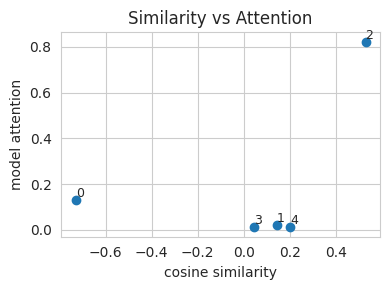

In [5]:
# 2-3) Check alignment of similarity vs model attention
import pandas as pd

sim_np = sims.detach().cpu().numpy()
att_np = attn_weights.detach().cpu().numpy()
rows = []
for i, cfg in enumerate(retrieved_configs):
    rows.append({
        'idx': i,
        'name': cfg.get('name', f'r{i}'),
        'sim_cos': float(sim_np[i]),
        'attn_model': float(att_np[i]),
    })
df_check = pd.DataFrame(rows)
df_check['sim_rank_desc'] = df_check['sim_cos'].rank(ascending=False, method='dense').astype(int)
df_check['attn_rank_desc'] = df_check['attn_model'].rank(ascending=False, method='dense').astype(int)
print("Similarity vs attention (higher is closer):")
display(df_check.sort_values('attn_model', ascending=False))

corr = df_check[['sim_cos','attn_model']].corr(method='spearman').iloc[0,1]
print(f"Spearman corr(sim, attn) = {corr:.3f}")

plt.figure(figsize=(4,3))
plt.scatter(df_check['sim_cos'], df_check['attn_model'], c='tab:blue')
for _, r in df_check.iterrows():
    plt.text(r['sim_cos'], r['attn_model'], r['idx'], fontsize=9, ha='left', va='bottom')
plt.xlabel('cosine similarity')
plt.ylabel('model attention')
plt.title('Similarity vs Attention')
plt.tight_layout()
plt.show()



In [6]:
# 3) Use model-based attention weights to form a simple weighted sum (for reference)
attn_weights_model = attn_weights.clone()
attended = (attn_weights_model.unsqueeze(1) * kb_top).sum(dim=0)
print("attention weights (model cross_mha):", attn_weights_model.tolist())

attention weights (model cross_mha): [0.13216890394687653, 0.02231729030609131, 0.8223740458488464, 0.011192590929567814, 0.011947231367230415]


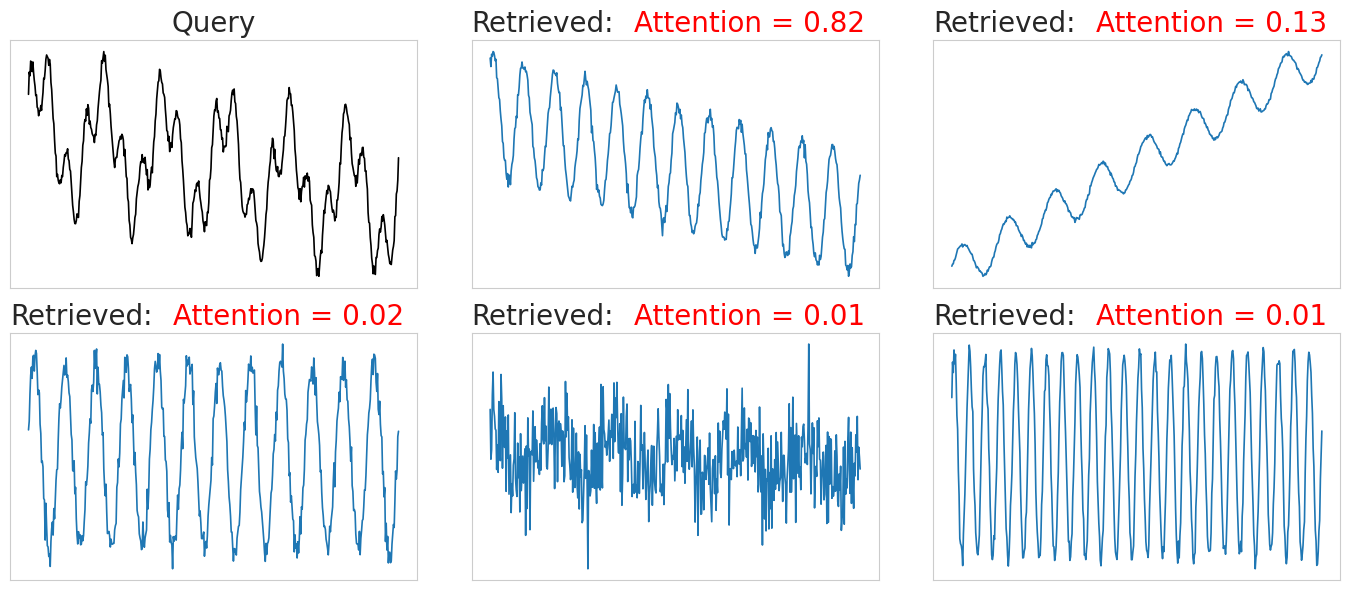

<Figure size 640x480 with 0 Axes>

In [7]:
# 4) Visualization: 2x3 grid (query + top-5), ordered by similarity -> dissimilarity
colors = sns.color_palette("tab10", k_top)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

# (0,0): query
axes[0].plot(query, color='black', lw=1.2)
axes[0].set_title("Query", fontsize=20)
axes[0].set_yticks([])
axes[0].set_xticks([])
    
# sort indices by attention weight descending (most similar first)
order = torch.argsort(attn_weights_model, descending=True).tolist()
# place them left->right, top->bottom starting at axes[1]
for pos, idx_i in enumerate(order):
    if pos >= k_top:
        break
    ax = axes[pos + 1]
#     ax.plot(kb_top[idx_i].numpy(), color=colors[idx_i], lw=1.0)
    ax.plot(kb_top[idx_i].numpy(),lw=1.2)
    ax.set_title("Retrieved:", fontsize=20, loc='left')
    ax.text(0.4, 1.01, f"Attention = {attn_weights_model[idx_i]:.2f}", color='red', fontsize=20,
            transform=ax.transAxes, ha='left', va='bottom')
    ax.set_yticks([])
    ax.set_xticks([])    

# hide any unused axes (if k_top<5)
for j in range(k_top + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "attention.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()



In [ ]:
# 4) Visualization: 2x3 grid (query + top-5), ordered by similarity -> dissimilarity
colors = sns.color_palette("tab10", k_top)
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

# (0,0): query
axes[0].plot(query, color='black', lw=1.2)
axes[0].set_title("Query", fontsize=20)
axes[0].set_yticks([])
axes[0].set_xticks([])
    
# sort indices by attention weight descending (most similar first)
order = torch.argsort(attn_weights_model, descending=True).tolist()
# place them left->right, top->bottom starting at axes[1]
for pos, idx_i in enumerate(order):
    if pos >= k_top:
        break
    ax = axes[pos + 1]
#     ax.plot(kb_top[idx_i].numpy(), color=colors[idx_i], lw=1.0)
    ax.plot(kb_top[idx_i].numpy(),lw=1.2)
    ax.set_title(rf"Attention = $\color{{red}}{{{attn_weights_model[idx_i]:.2f}}}$", fontsize=20)
    ax.set_yticks([])
    ax.set_xticks([])    

# hide any unused axes (if k_top<5)
for j in range(k_top + 1, len(axes)):
    axes[j].axis('off')


plt.tight_layout()
plt.show()

SAVE_PATH = '/home/seunghan.lee/workspace/experiments/figures'
fn = "attention.pdf"
fn = os.path.join(SAVE_PATH,fn)
plt.savefig(fn, bbox_inches="tight")
plt.show()

